# Peptides-struct — Commute Time Analysis

Commute time CT(u,v) is the expected round-trip time of a random walk from atom u to atom v and back, computed exactly via the Moore-Penrose pseudoinverse of the graph Laplacian (no simulation) — see `commute_time.py` for the algorithm and full derivation.

Computed on four different graphs per molecule (test split only, 2,331 molecules):
- **atom** — plain atom-bond graph (atoms=nodes, bonds=edges)
- **ct6** — CT's 6-relation cell complex (`adj00`/`icd01`/`adj11`/`icd02`/`icd12`/`adj22`)
- **cin** — CIN's message-passing graph (`up0`/`up1`/`boundary1`/`boundary2`)
- **cinpp** — CIN++'s message-passing graph (adds `down1`/`down2`)

**Important**: `ct6`/`cin`/`cinpp` are NOT a subset chain — CT has a direct atom↔ring relation neither CIN variant has, and CIN/CIN++ have a bond↔bond-via-ring relation CT never has (see `commute_time.py`'s docstring for the exact, verified mapping). Also: for `ct6`/`cin`/`cinpp`, bond/ring cells shape the walk but are never counted as endpoints — every reported pair is atom↔atom ("real nodes" only).

GCN/GAT/GIN/CIN/CINpp use hp-tuned results. CT does **not** have a hp-tuned run yet, so it uses its latest non-tuned result instead (`results_struct_ct_{original,simple,full}_3.json`); no SchNet result exists at all. See `analyze_results_hptuned.ipynb` for details on why CT's `_3` suffix is the valid one to use.

In [117]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

plt.rcParams['figure.dpi'] = 130
pd.set_option('display.float_format', '{:.4f}'.format)

RESULTS_DIR = Path('results')

In [118]:
FILES = {
    'CT-original': 'results_struct_ct_original_3.json',
    'CT-simple':   'results_struct_ct_simple_3.json',
    'CT-full':     'results_struct_ct_full_3.json',
    'GCN':   'results_struct_gcn_hptuned.json',
    'GAT':   'results_struct_gat_hptuned.json',
    'GIN':   'results_struct_gin_hptuned.json',
    'CIN':   'results_struct_cin_hptuned.json',
    'CINpp': 'results_struct_cinpp_hptuned.json',
}
# CT files are NOT hp-tuned (no tuned run submitted yet) -- these are the latest
# non-tuned reruns (suffix _3), included as the best available CT numbers.

data = {}
for label, fname in FILES.items():
    p = RESULTS_DIR / fname
    if p.exists():
        with open(p) as f:
            data[label] = json.load(f)
    else:
        print(f'Missing: {fname}')

print(f'Loaded {len(data)} result files: {list(data.keys())}')

Loaded 8 result files: ['CT-original', 'CT-simple', 'CT-full', 'GCN', 'GAT', 'GIN', 'CIN', 'CINpp']


In [119]:
COLORS = {
    'CT':    '#4C72B0',
    'GCN':   '#DD8452',
    'GAT':   '#55A868',
    'GIN':   '#C44E52',
    'CINpp': '#937860',
    'CIN':   '#8172B2',
}

def model_color(label):
    for prefix, c in COLORS.items():
        if label.startswith(prefix):
            return c
    return 'gray'

model_labels = list(data.keys())
n_models = len(model_labels)
MODEL_COLOR = {lbl: model_color(lbl) for lbl in model_labels}

def per_molecule_err(d):
    """index -> mean absolute error across the 11 targets and 3 seeded runs."""
    err_by_idx = {}
    for run in d['runs']:
        for p in run['predictions']:
            err = float(np.mean(np.abs(np.array(p['pred']) - np.array(p['true']))))
            err_by_idx.setdefault(p['index'], []).append(err)
    return {k: float(np.mean(v)) for k, v in err_by_idx.items()}

err_maps = {lbl: per_molecule_err(data[lbl]) for lbl in model_labels}
for lbl in model_labels:
    print(f'{lbl:10s} n_molecules={len(err_maps[lbl])}')

CT-original n_molecules=2331
CT-simple  n_molecules=2331
CT-full    n_molecules=2331
GCN        n_molecules=2331
GAT        n_molecules=2331
GIN        n_molecules=2331
CIN        n_molecules=2331
CINpp      n_molecules=2331


In [120]:
ct_npz = np.load('peptides_struct_commute_time_per_molecule.npz')
# index is a plain 0..N-1 range aligned to the PyG test split position (same as
# peptides_struct_test_per_molecule.npz / peptides_struct_hasse_cin_per_molecule.npz)
assert (ct_npz['index'] == np.arange(len(ct_npz['index']))).all()

PREFIXES = ('atom', 'ct6', 'cin', 'cinpp')
STATS = ('max', 'min', 'mean', 'median')

commute = {p: {s: ct_npz[f'{p}_commute_{s}'] for s in STATS} for p in PREFIXES}

print(f"n_molecules={len(ct_npz['index'])}")
for p in PREFIXES:
    n_nan = np.isnan(commute[p]['mean']).sum()
    print(f'{p:6s}  n_nan={n_nan}')

n_molecules=2331
atom    n_nan=0
ct6     n_nan=0
cin     n_nan=0
cinpp   n_nan=0


## Overview of Statistics

For each of the 4 graphs, each molecule contributes 4 numbers (max/min/mean/median commute time, pooled over its atom-atom pairs). The table below summarizes the *distribution* of each of those 4 numbers across all 2,331 test molecules.

In [121]:
rows = []
for p in PREFIXES:
    for s in STATS:
        arr = commute[p][s]
        valid = arr[~np.isnan(arr)]
        rows.append({
            'graph': p, 'stat': s,
            'dataset_mean': valid.mean(), 'dataset_std': valid.std(),
            'dataset_min': valid.min(), 'dataset_max': valid.max(),
            'n_valid': len(valid),
        })

overview_df = pd.DataFrame(rows).set_index(['graph', 'stat'])
display(overview_df.style.format(precision=2).background_gradient(subset=['dataset_mean'], cmap='RdYlGn_r'))

### Distribution of per-molecule mean and max commute time, by graph

These two stats (mean, max) are what the scatter plots below use as the x-axis.

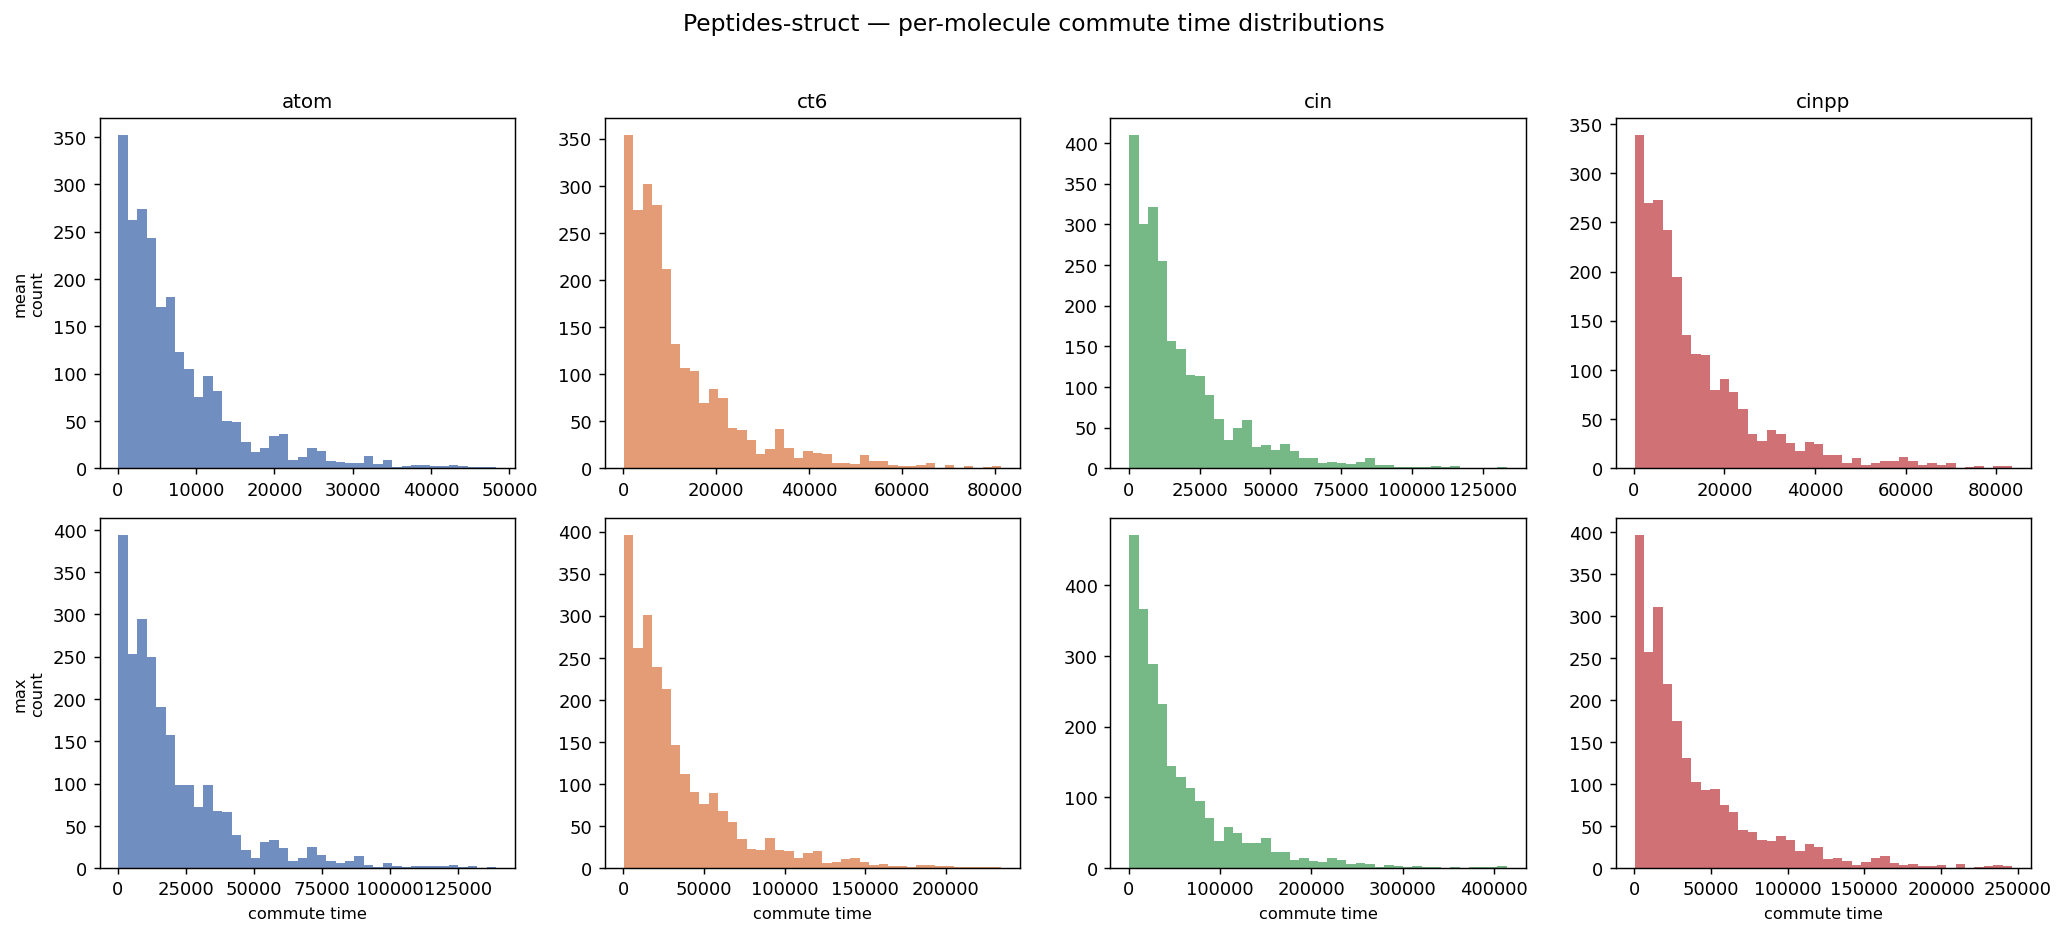

In [122]:
GRAPH_COLOR = {'atom': '#4C72B0', 'ct6': '#DD8452', 'cin': '#55A868', 'cinpp': '#C44E52'}

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for row, stat in enumerate(('mean', 'max')):
    for col, p in enumerate(PREFIXES):
        ax = axes[row, col]
        arr = commute[p][stat]
        valid = arr[~np.isnan(arr)]
        ax.hist(valid, bins=40, color=GRAPH_COLOR[p], alpha=0.8)
        if row == 0:
            ax.set_title(p, fontsize=11)
        if col == 0:
            ax.set_ylabel(f'{stat}\ncount', fontsize=9)
        if row == 1:
            ax.set_xlabel('commute time', fontsize=9)

plt.suptitle('Peptides-struct — per-molecule commute time distributions', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Commute Time vs. Model Error — Every Model, Per Graph Type

For each of the 4 graphs and each of {mean, max} commute time, one row of scatter plots — every model shown side by side, sharing the same x-axis (that graph's commute time for the molecule) against that model's own per-molecule mean absolute error (across the 11 targets). Dashed line = linear fit.

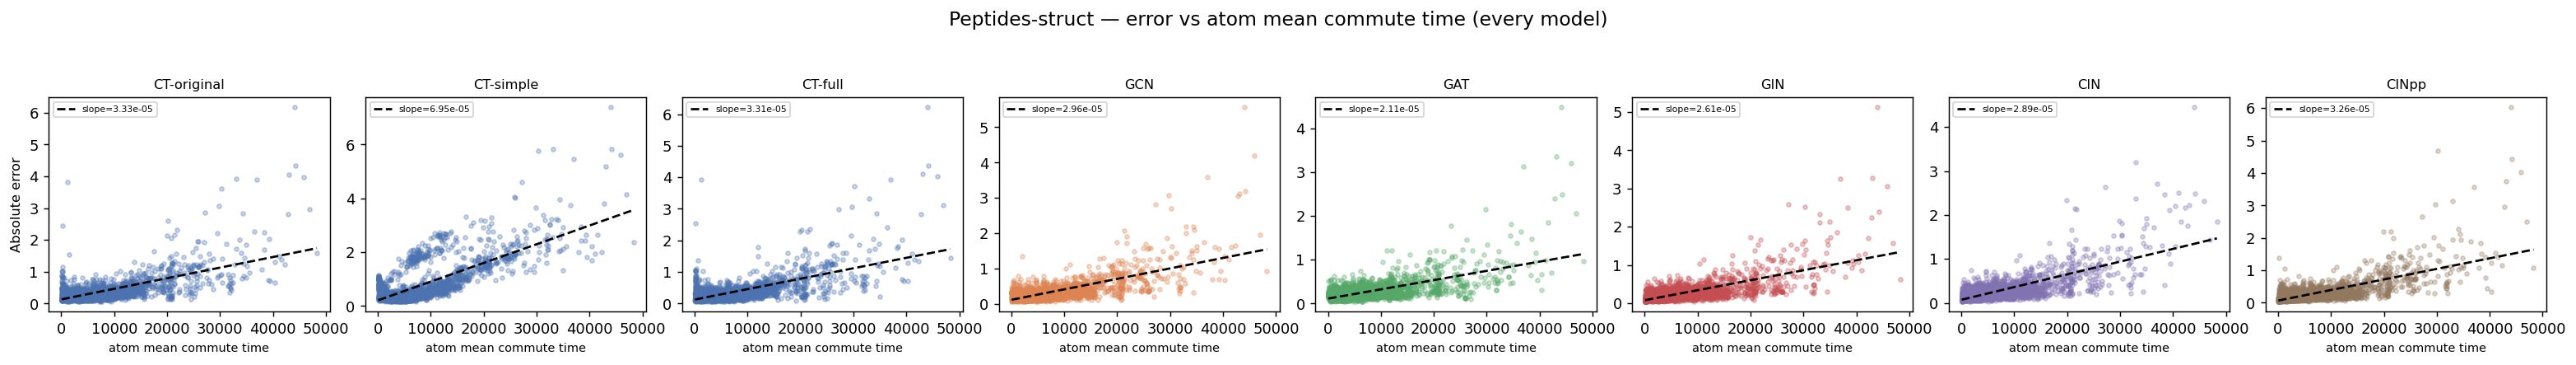

In [123]:
def plot_err_vs_commute(prefix, stat):
    hd_arr = commute[prefix][stat]
    fig, axes = plt.subplots(1, n_models, figsize=(3.0 * n_models, 3.2), squeeze=False)
    axes = axes[0]
    for col, lbl in enumerate(model_labels):
        ax = axes[col]
        color = MODEL_COLOR[lbl]
        err_by_idx = err_maps[lbl]
        idxs = np.array(sorted(i for i in err_by_idx if not np.isnan(hd_arr[i])))
        x = hd_arr[idxs]
        y = np.array([err_by_idx[i] for i in idxs])
        ax.scatter(x, y, color=color, alpha=0.3, s=8, rasterized=True)
        if len(x) >= 2 and np.ptp(x) > 0:
            coeffs = np.polyfit(x, y, 1)
            x_line = np.linspace(x.min(), x.max(), 200)
            ax.plot(x_line, np.polyval(coeffs, x_line), color='black', linewidth=1.5,
                    linestyle='--', label=f'slope={coeffs[0]:.2e}')
            ax.legend(fontsize=6, loc='upper left')
        ax.set_title(lbl, fontsize=9)
        if col == 0:
            ax.set_ylabel('Absolute error', fontsize=9)
        ax.set_xlabel(f'{prefix} {stat} commute time', fontsize=8)
    plt.suptitle(f'Peptides-struct — error vs {prefix} {stat} commute time (every model)', fontsize=13, y=1.05)
    plt.tight_layout()
    plt.show()

plot_err_vs_commute('atom', 'mean')

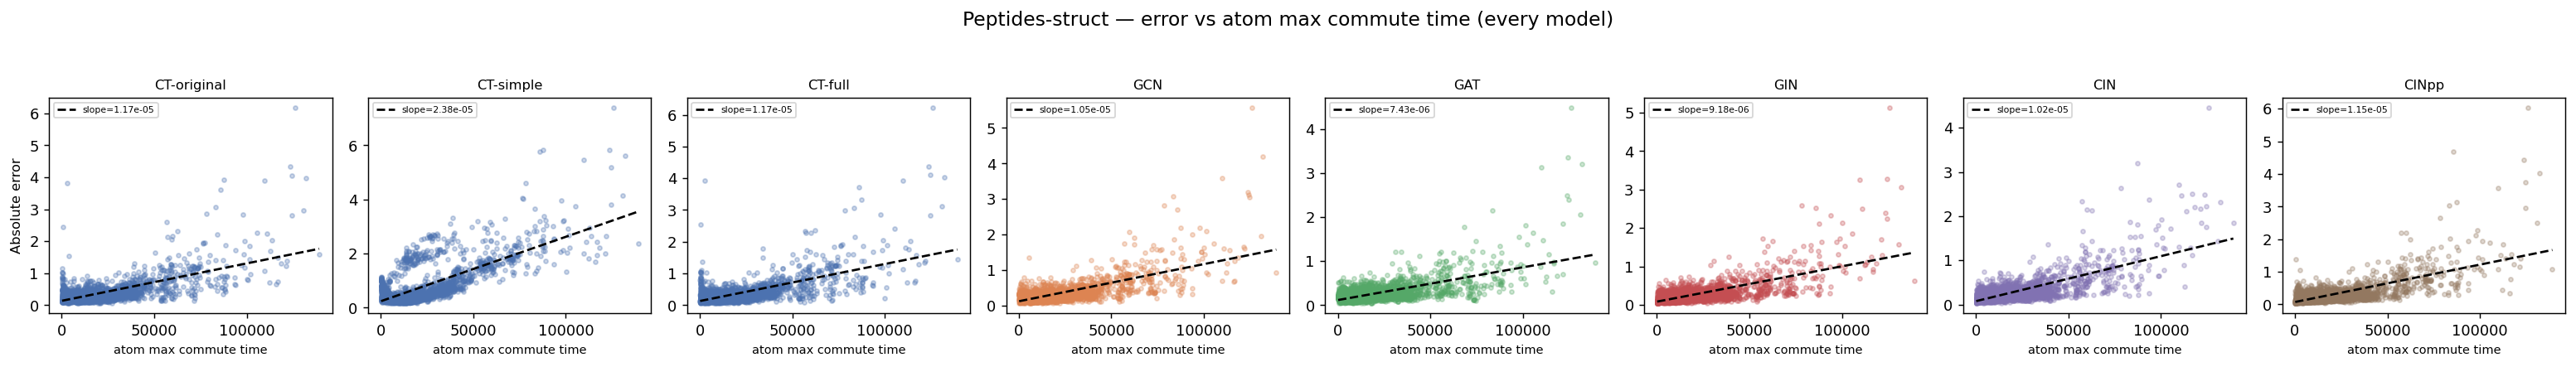

In [124]:
plot_err_vs_commute('atom', 'max')

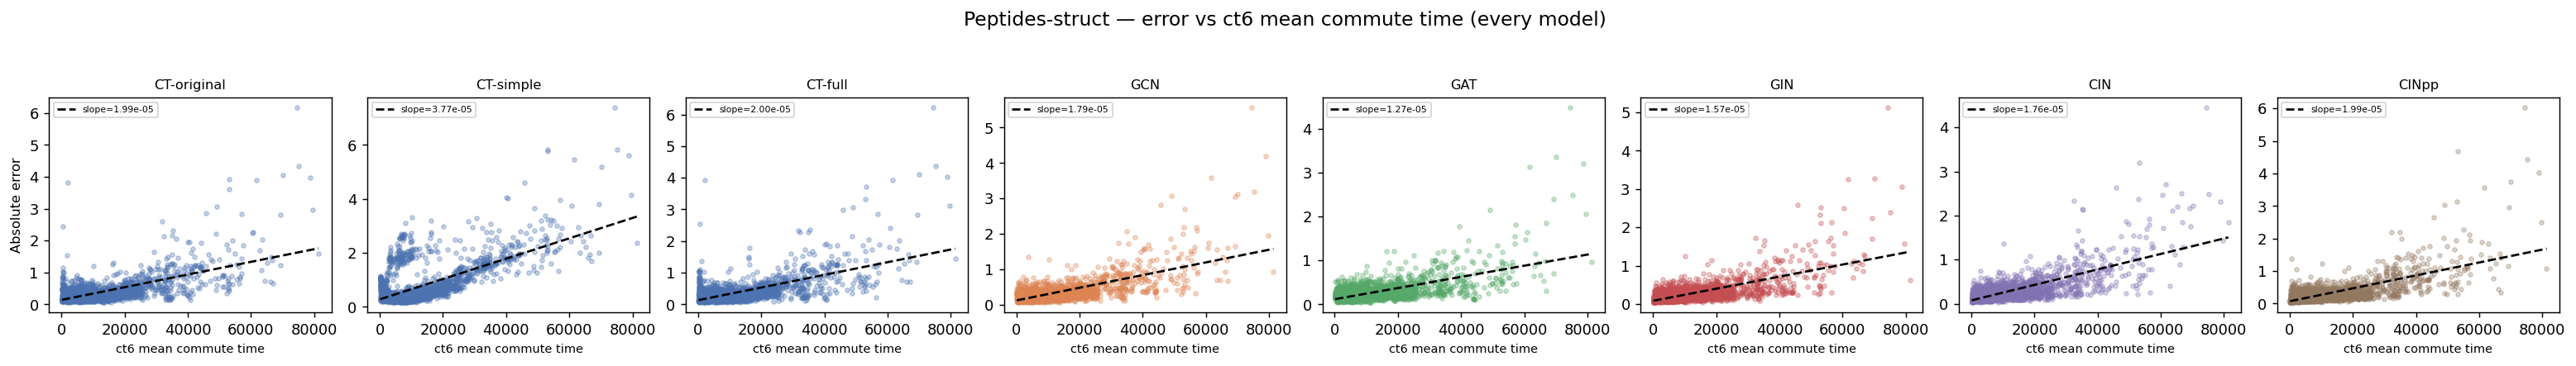

In [125]:
plot_err_vs_commute('ct6', 'mean')

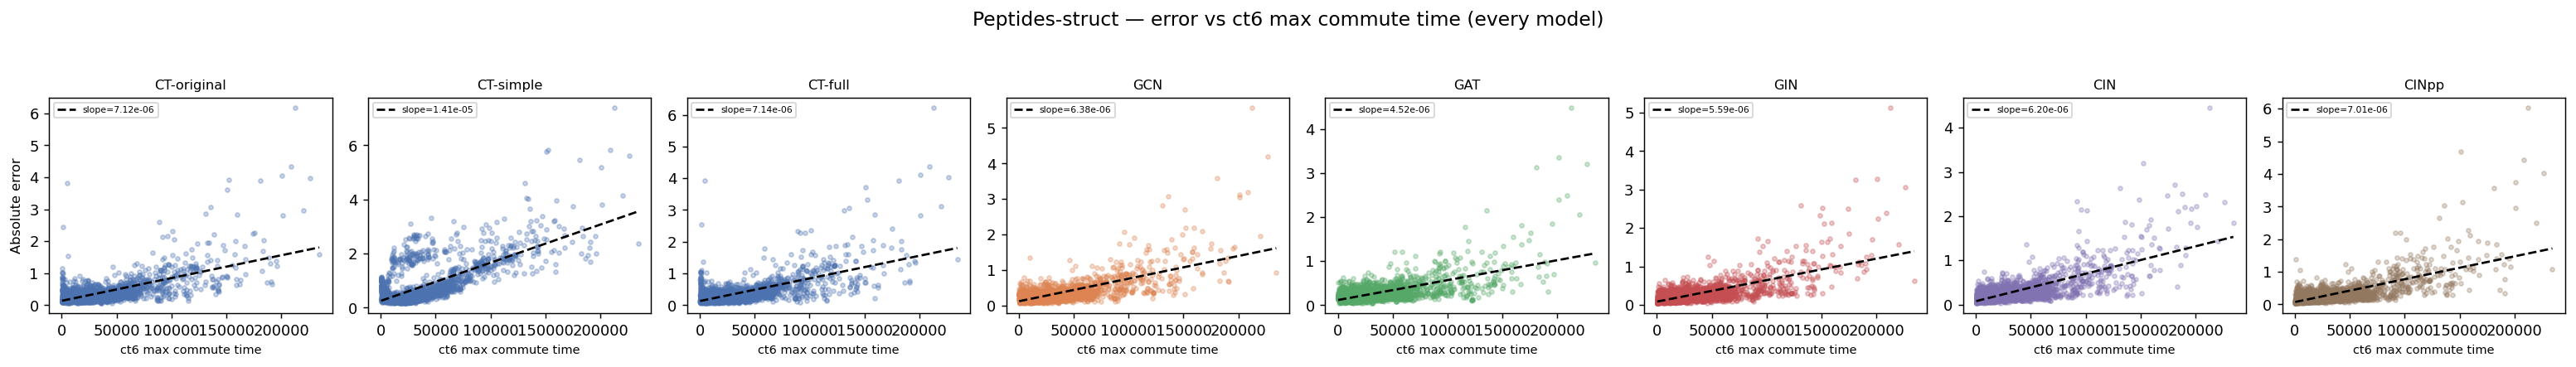

In [126]:
plot_err_vs_commute('ct6', 'max')

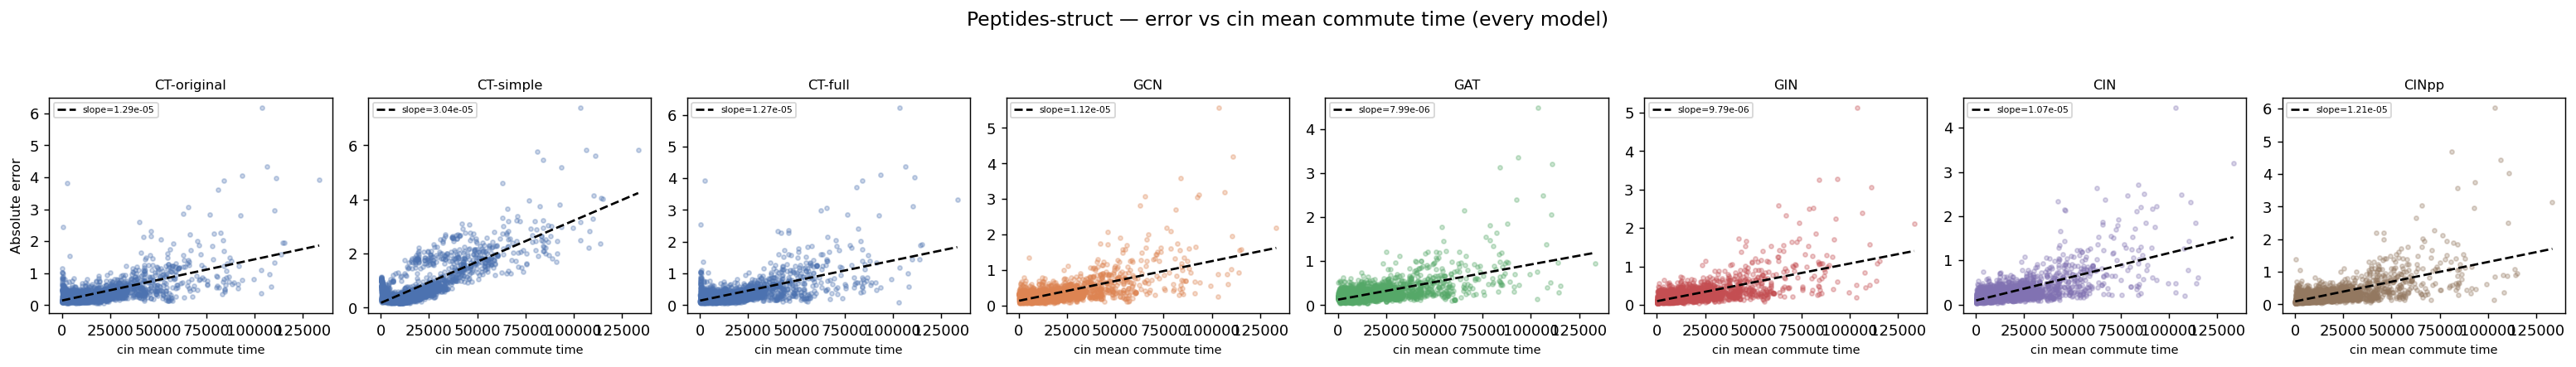

In [127]:
plot_err_vs_commute('cin', 'mean')

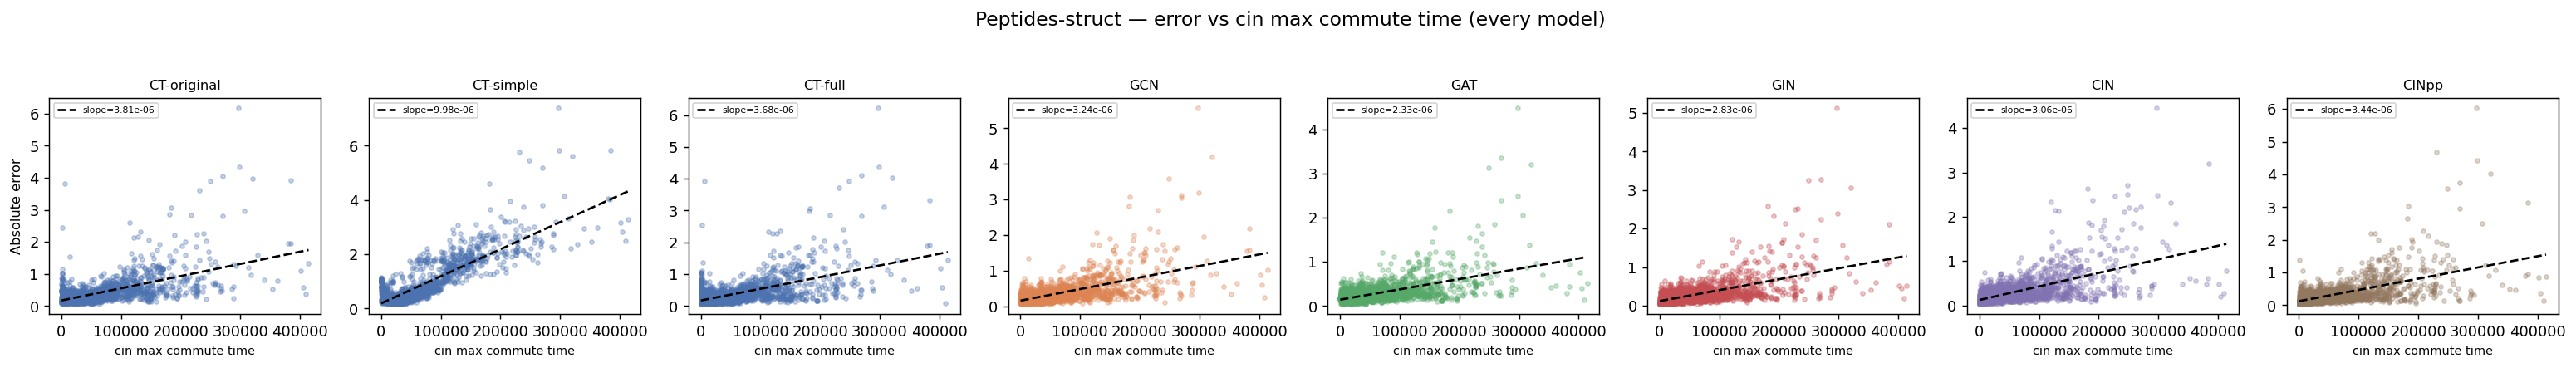

In [128]:
plot_err_vs_commute('cin', 'max')

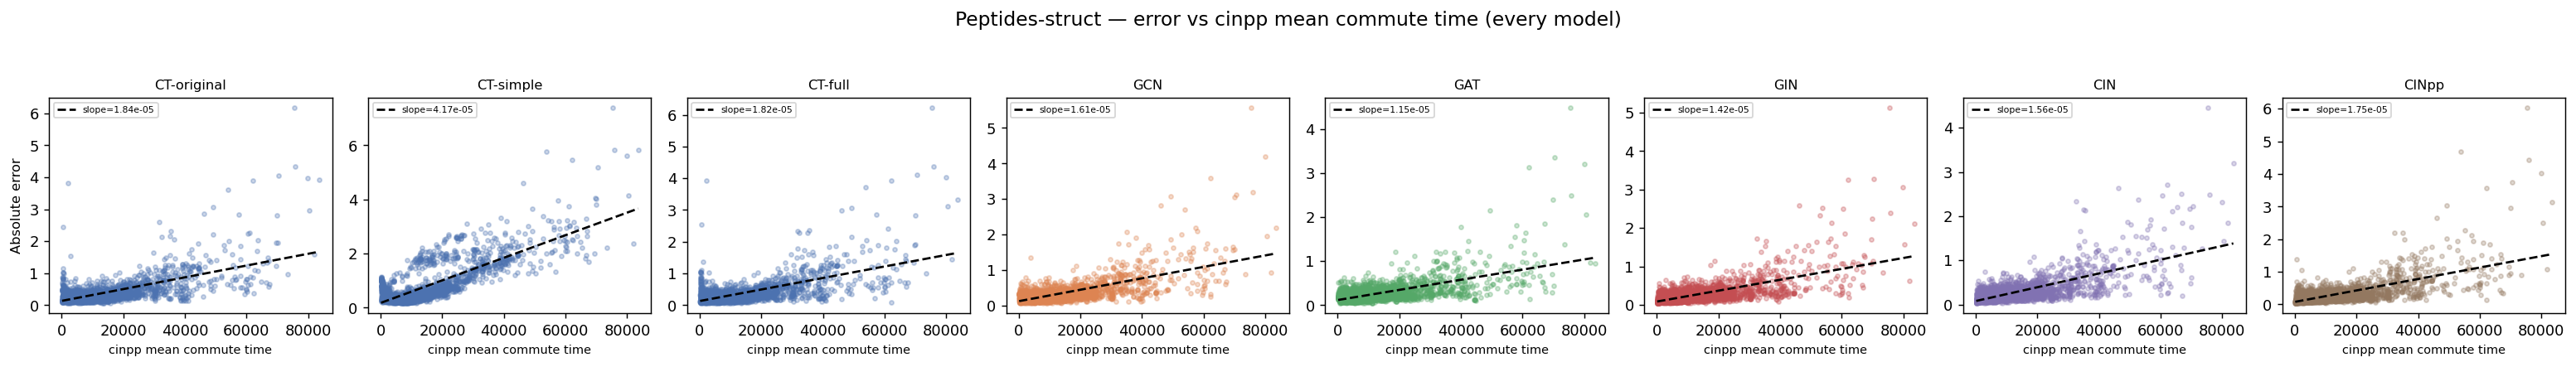

In [129]:
plot_err_vs_commute('cinpp', 'mean')

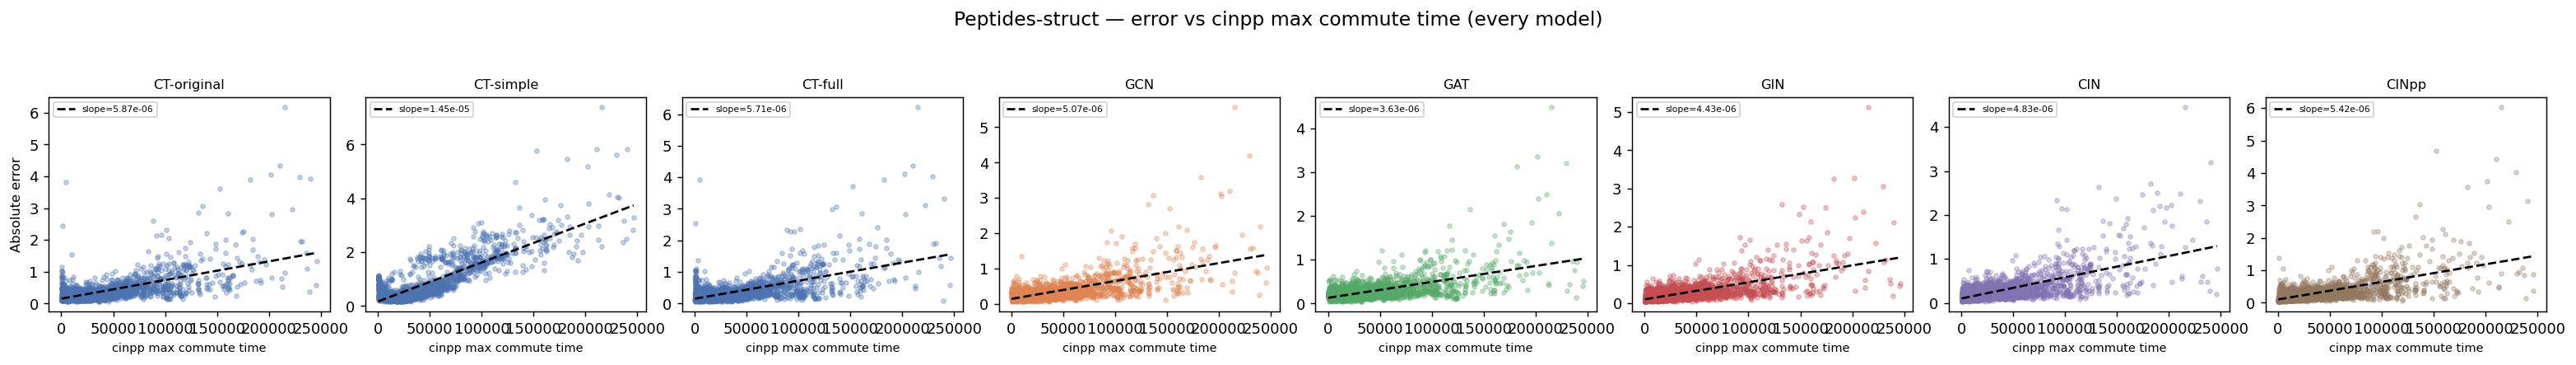

In [130]:
plot_err_vs_commute('cinpp', 'max')

## Size-Normalized View

The message-passing graphs (`ct6`/`cin`/`cinpp`) have roughly **2x more total nodes** than the plain `atom` graph (bond- and ring-cells count as full graph vertices, even though only atom-atom pairs are measured) — and commute time scales with graph volume, so their raw commute times read proportionally higher. This isn't a bug; it's expected. Measured directly on this dataset:

| graph | mean n_nodes/n_atoms | commute/atom-commute ratio (mean) |
|---|---|---|
| ct6 | ~2.04 | ~1.65 |
| cin | ~2.04 | ~2.41 |
| cinpp | ~2.04 | ~1.79 |

To compare the 4 graphs on a level footing, this section divides each molecule's commute time by that graph's own node count (`n_atoms` for `atom`; `n_atoms+n_bonds+n_rings` for `ct6`/`cin`/`cinpp`). `cin`'s ratio is well above the pure size ratio (fewest relations → least redundant/parallel shortcut edges → relatively higher resistance), so its normalized values should still land above `atom`'s even after this correction.

In [131]:
n_atoms_arr = ct_npz['n_atoms'].astype(float)
n_bonds_arr = ct_npz['n_bonds'].astype(float)
n_rings_arr = ct_npz['n_rings'].astype(float)
n_total_arr = n_atoms_arr + n_bonds_arr + n_rings_arr

N_NODES = {'atom': n_atoms_arr, 'ct6': n_total_arr, 'cin': n_total_arr, 'cinpp': n_total_arr}

norm_commute = {p: {s: commute[p][s] / N_NODES[p] for s in STATS} for p in PREFIXES}

print('Post-normalization ratio to atom (should be near 1.0):')
for p in ('ct6', 'cin', 'cinpp'):
    ratio = norm_commute[p]['mean'] / norm_commute['atom']['mean']
    print(f'  {p:6s}  mean={np.nanmean(ratio):.3f}')

Post-normalization ratio to atom (should be near 1.0):
  ct6     mean=0.809
  cin     mean=1.175
  cinpp   mean=0.875


In [132]:
rows = []
for p in PREFIXES:
    for s in STATS:
        arr = norm_commute[p][s]
        valid = arr[~np.isnan(arr)]
        rows.append({
            'graph': p, 'stat': s,
            'dataset_mean': valid.mean(), 'dataset_std': valid.std(),
            'dataset_min': valid.min(), 'dataset_max': valid.max(),
            'n_valid': len(valid),
        })

norm_overview_df = pd.DataFrame(rows).set_index(['graph', 'stat'])
display(norm_overview_df.style.format(precision=4).background_gradient(subset=['dataset_mean'], cmap='RdYlGn_r'))

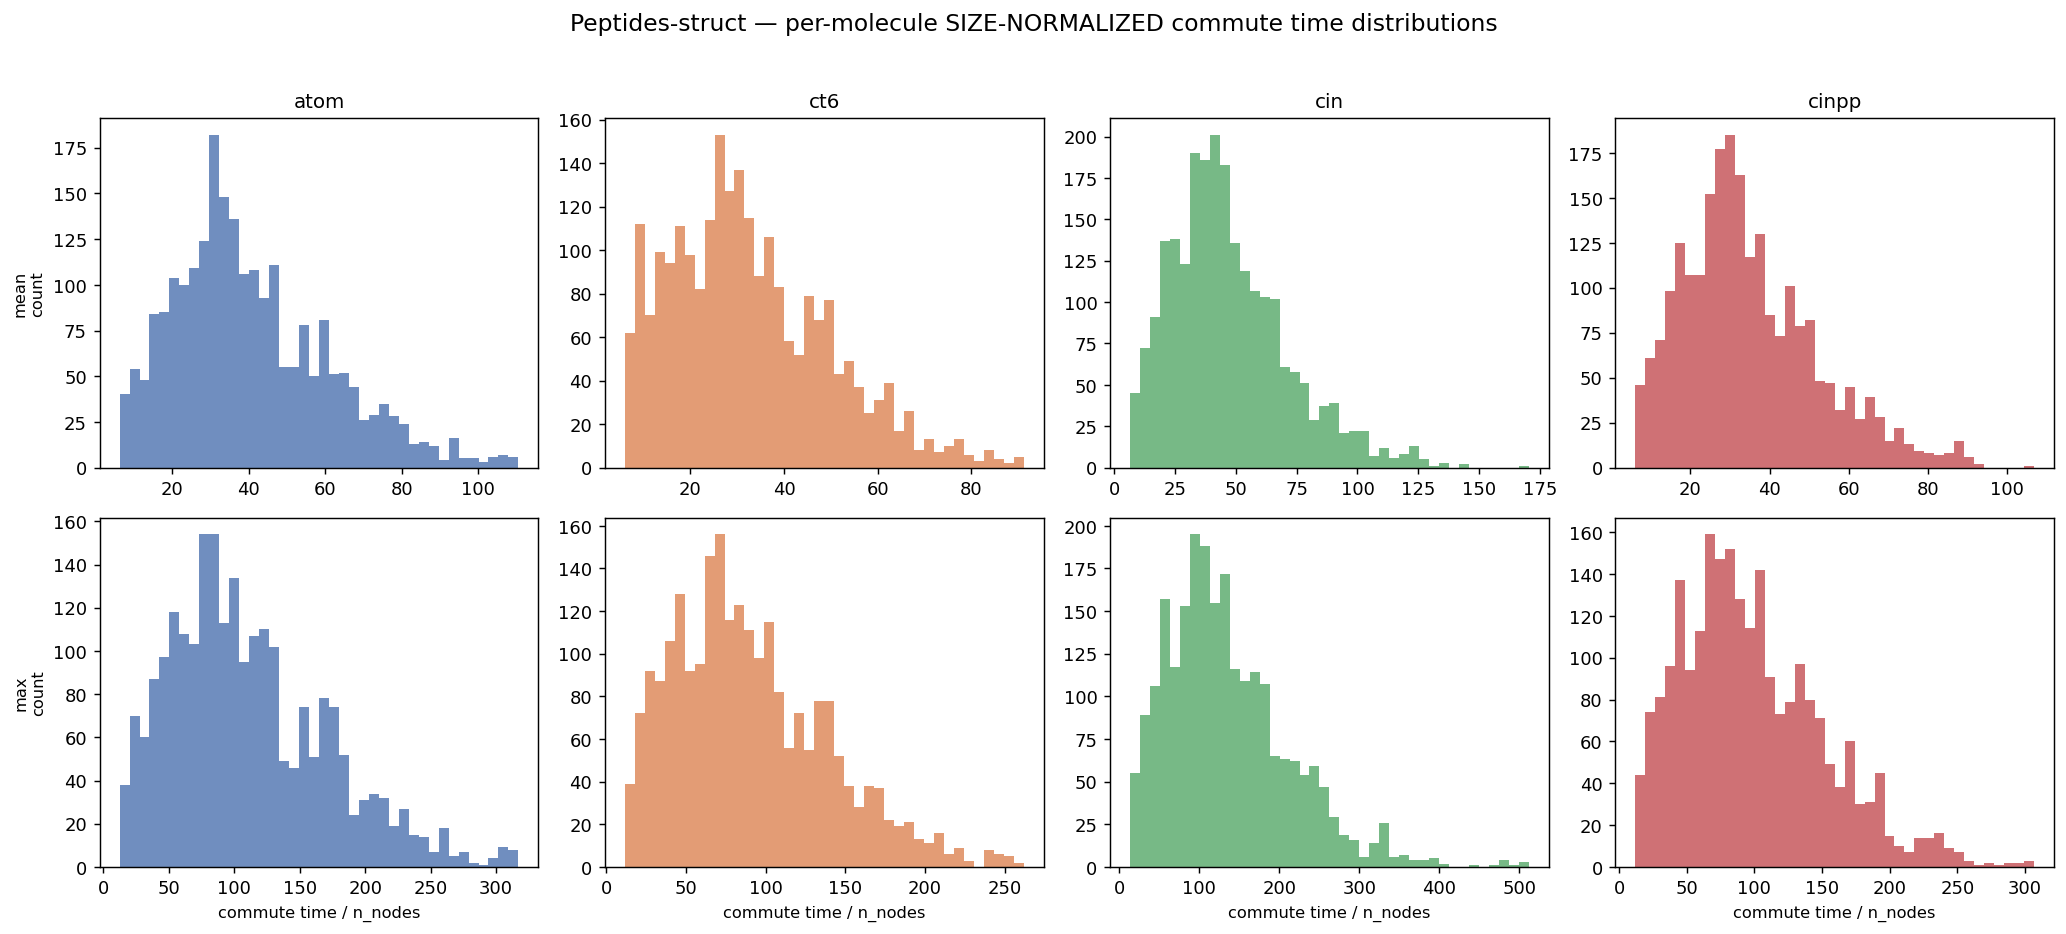

In [133]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for row, stat in enumerate(('mean', 'max')):
    for col, p in enumerate(PREFIXES):
        ax = axes[row, col]
        arr = norm_commute[p][stat]
        valid = arr[~np.isnan(arr)]
        ax.hist(valid, bins=40, color=GRAPH_COLOR[p], alpha=0.8)
        if row == 0:
            ax.set_title(p, fontsize=11)
        if col == 0:
            ax.set_ylabel(f'{stat}\ncount', fontsize=9)
        if row == 1:
            ax.set_xlabel('commute time / n_nodes', fontsize=9)

plt.suptitle('Peptides-struct — per-molecule SIZE-NORMALIZED commute time distributions', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Normalized commute time vs. model error — every model, per graph type

Same as the raw scatter section above, but x-axis is size-normalized mean commute time (4 grids, one per graph type).

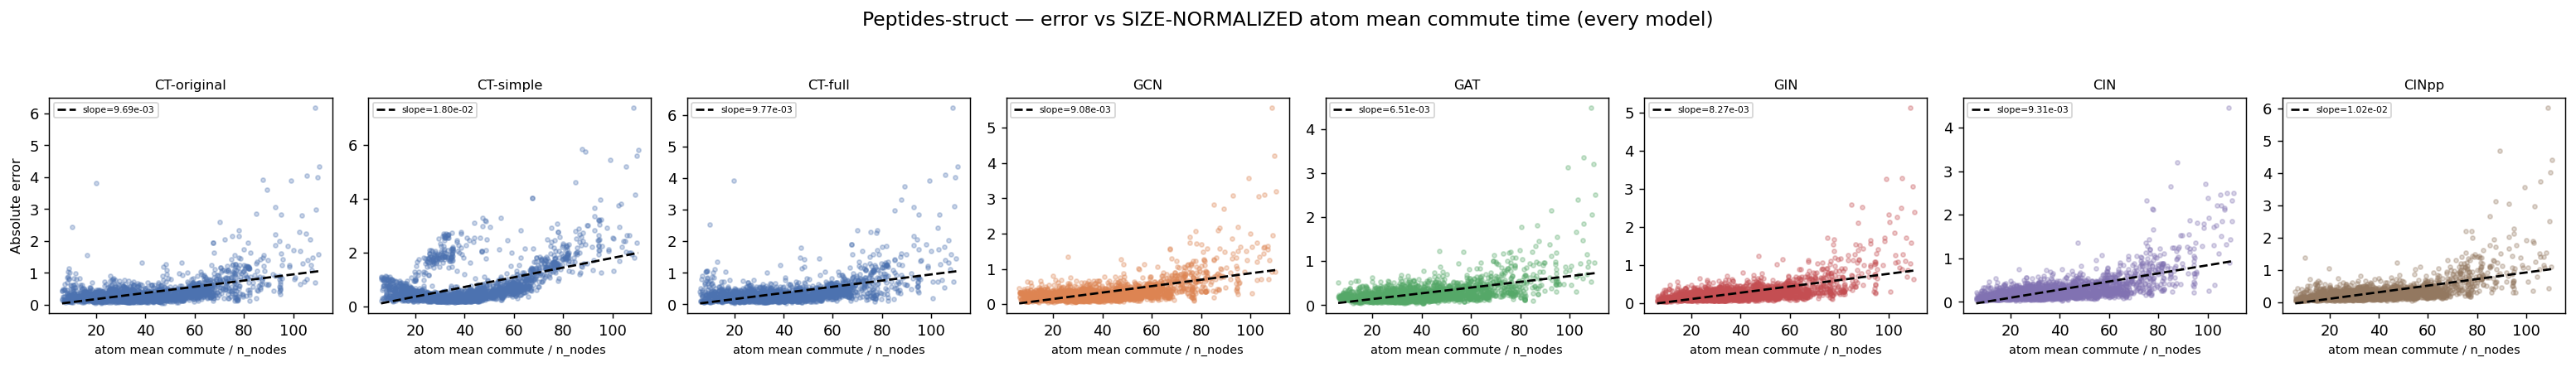

In [134]:
def plot_err_vs_norm_commute(prefix, stat='mean'):
    hd_arr = norm_commute[prefix][stat]
    fig, axes = plt.subplots(1, n_models, figsize=(3.0 * n_models, 3.2), squeeze=False)
    axes = axes[0]
    for col, lbl in enumerate(model_labels):
        ax = axes[col]
        color = MODEL_COLOR[lbl]
        err_by_idx = err_maps[lbl]
        idxs = np.array(sorted(i for i in err_by_idx if not np.isnan(hd_arr[i])))
        x = hd_arr[idxs]
        y = np.array([err_by_idx[i] for i in idxs])
        ax.scatter(x, y, color=color, alpha=0.3, s=8, rasterized=True)
        if len(x) >= 2 and np.ptp(x) > 0:
            coeffs = np.polyfit(x, y, 1)
            x_line = np.linspace(x.min(), x.max(), 200)
            ax.plot(x_line, np.polyval(coeffs, x_line), color='black', linewidth=1.5,
                    linestyle='--', label=f'slope={coeffs[0]:.2e}')
            ax.legend(fontsize=6, loc='upper left')
        ax.set_title(lbl, fontsize=9)
        if col == 0:
            ax.set_ylabel('Absolute error', fontsize=9)
        ax.set_xlabel(f'{prefix} {stat} commute / n_nodes', fontsize=8)
    plt.suptitle(f'Peptides-struct — error vs SIZE-NORMALIZED {prefix} {stat} commute time (every model)', fontsize=13, y=1.05)
    plt.tight_layout()
    plt.show()

plot_err_vs_norm_commute('atom')

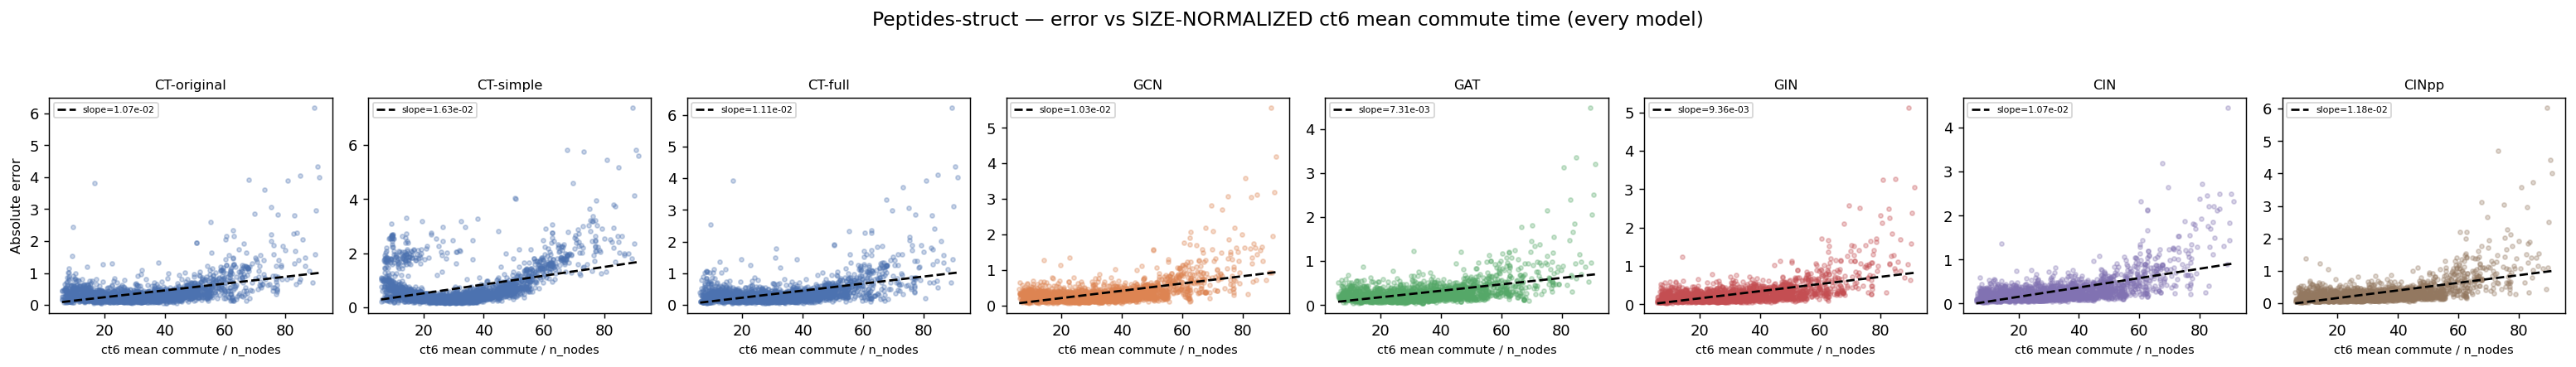

In [135]:
plot_err_vs_norm_commute('ct6')

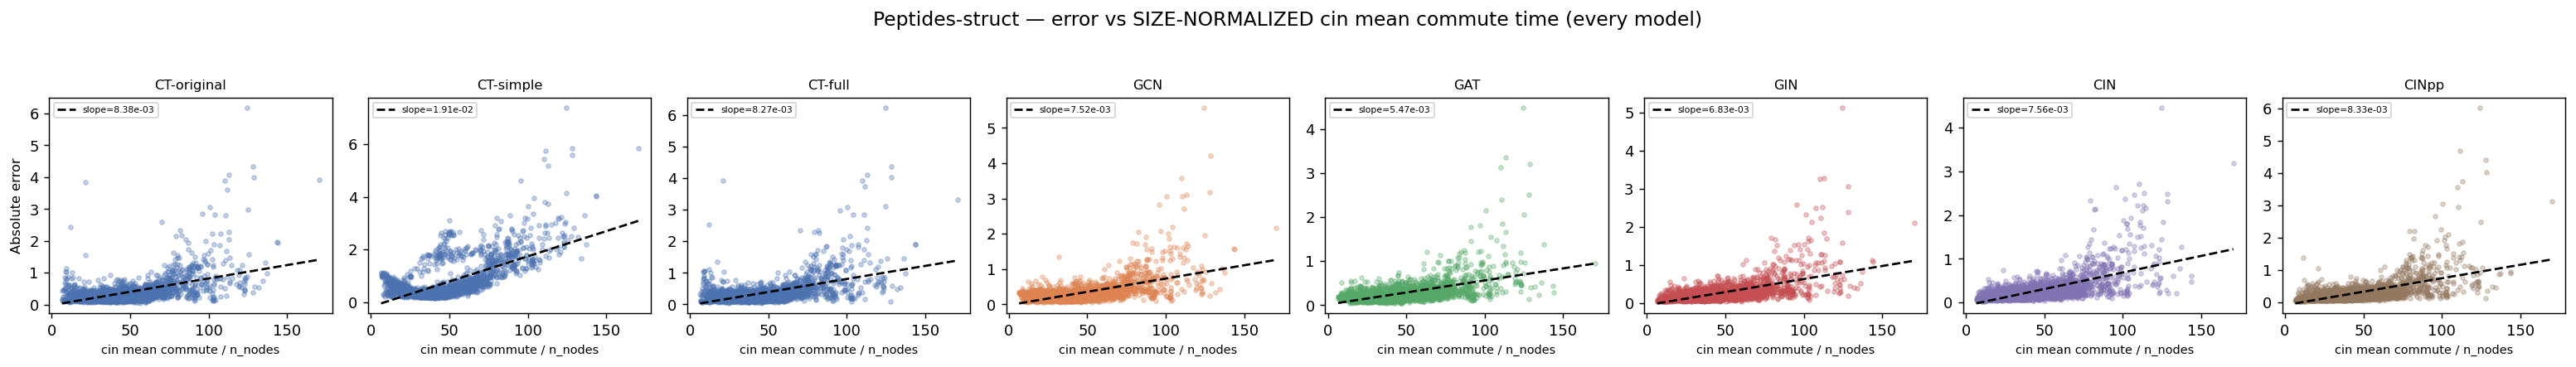

In [136]:
plot_err_vs_norm_commute('cin')

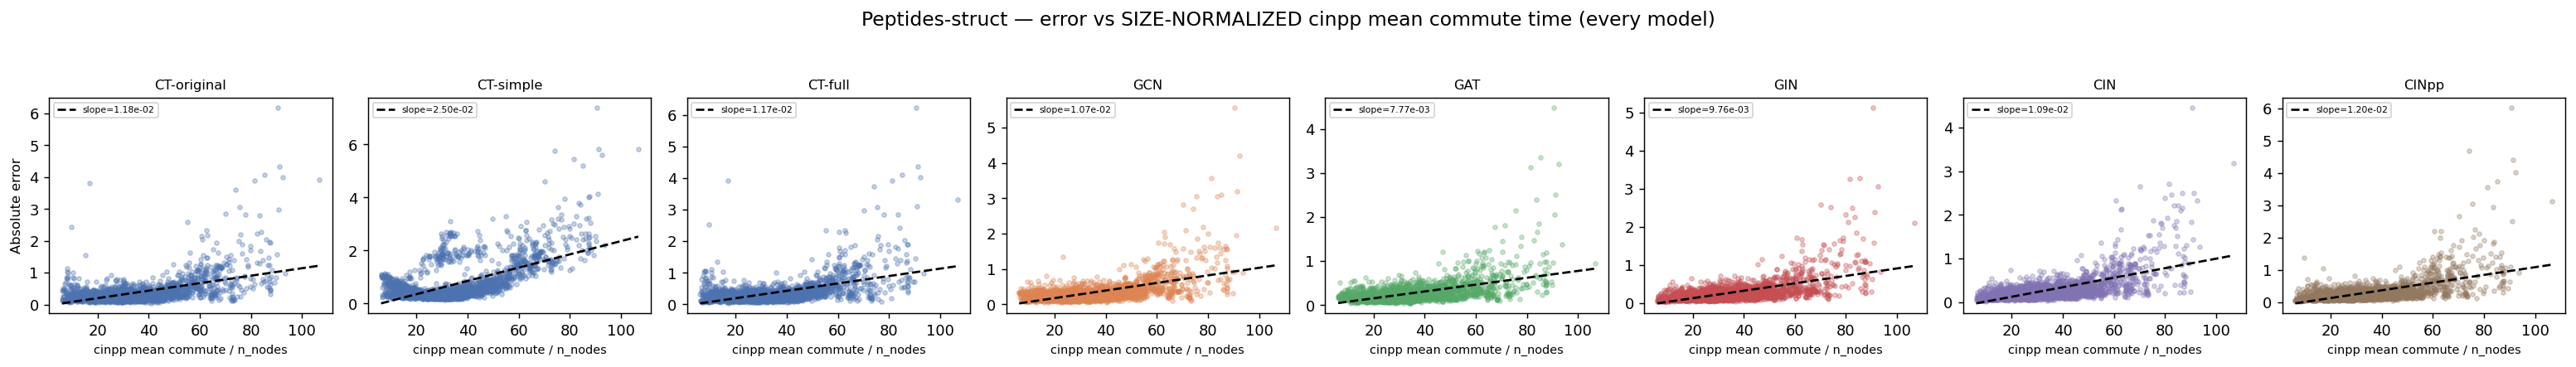

In [137]:
plot_err_vs_norm_commute('cinpp')

## Dataset-Mean Bar Chart — Mean vs. Max Commute Time

Raw (non-normalized) dataset-wide mean of the per-molecule `mean` stat vs. the per-molecule `max` stat, for each of the 4 graphs.

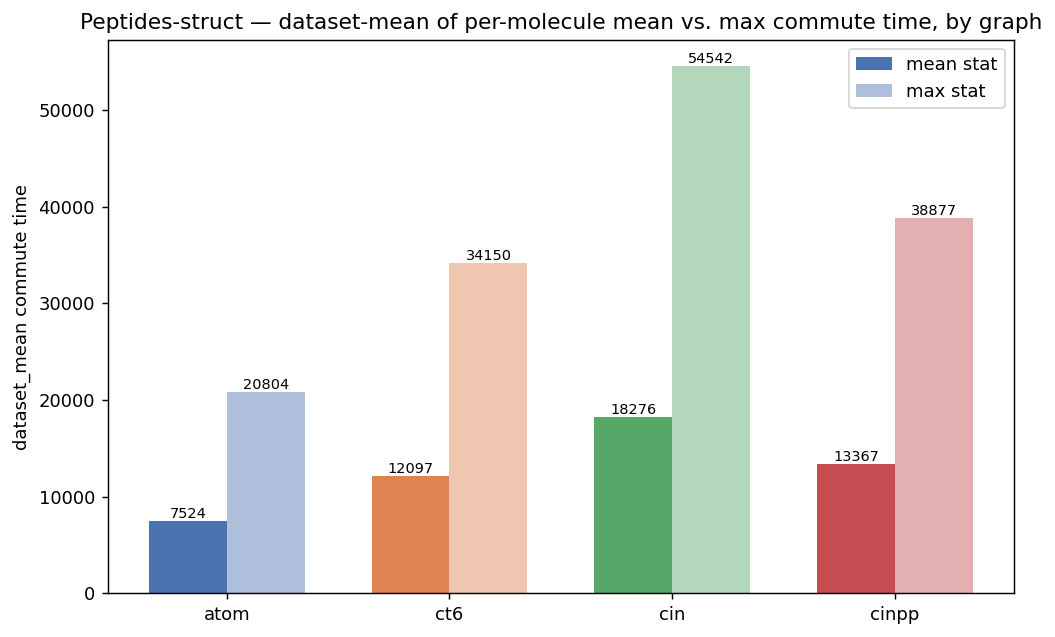

In [138]:
x = np.arange(len(PREFIXES))
width = 0.35
means = [overview_df.loc[(p, 'mean'), 'dataset_mean'] for p in PREFIXES]
maxs  = [overview_df.loc[(p, 'max'),  'dataset_mean'] for p in PREFIXES]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width / 2, means, width, label='mean stat', color=[GRAPH_COLOR[p] for p in PREFIXES])
ax.bar(x + width / 2, maxs,  width, label='max stat',  color=[GRAPH_COLOR[p] for p in PREFIXES], alpha=0.45)
for xi, v in zip(x - width / 2, means):
    ax.text(xi, v, f'{v:.0f}', ha='center', va='bottom', fontsize=8)
for xi, v in zip(x + width / 2, maxs):
    ax.text(xi, v, f'{v:.0f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(PREFIXES)
ax.set_ylabel('dataset_mean commute time')
ax.set_title('Peptides-struct — dataset-mean of per-molecule mean vs. max commute time, by graph')
ax.legend()
plt.tight_layout()
plt.show()

## GNN vs. Other Architectures — Commute Time by Outcome

For every non-GNN model (CT-original/simple/full, CIN, CINpp), split test molecules into two sets: **gnn_beats** (at least one of GCN/GAT/GIN has strictly lower error than this model on that molecule) vs. **model_beats** (this model's error was ≤ every GNN's there — it held its own). Each model's plot only shows **its own** graph type's commute time (`ct6` for CT variants, `cin` for CIN, `cinpp` for CINpp) — not all 4.

Histograms are density-normalized and 3-color coded: **gray** = overlap between the two distributions at that bin, **red** = `gnn_beats`-only excess, **blue** = `model_beats`-only excess (stacked on top of the gray base) — so at a glance, red-heavy bins are where losing to a GNN concentrates, blue-heavy bins are where the model held its own.

In [139]:
GNN_MODELS = [lbl for lbl in model_labels if lbl in ('GCN', 'GAT', 'GIN')]
NON_GNN_MODELS = [lbl for lbl in model_labels if lbl not in GNN_MODELS]

def model_prefix(label):
    """Which graph type this model's own commute time comes from."""
    if label.startswith('CT'):
        return 'ct6'
    if label.startswith('CINpp'):
        return 'cinpp'
    if label.startswith('CIN'):
        return 'cin'
    raise ValueError(f'no prefix mapping for {label}')

def build_gnn_beats_set(model_label):
    """molecule indices present in model_label's AND every GNN's err_maps.
    gnn_beats = indices where the best GNN's error is strictly lower than
    model_label's error there; model_beats = the rest of the common set
    (model_label's error was <= every GNN's, i.e. it held its own)."""
    common = set(err_maps[model_label])
    for g in GNN_MODELS:
        common &= set(err_maps[g])
    beats = {k for k in common
             if min(err_maps[g][k] for g in GNN_MODELS) < err_maps[model_label][k]}
    return beats, common - beats

gnn_beats_sets = {m: build_gnn_beats_set(m) for m in NON_GNN_MODELS}
for m in NON_GNN_MODELS:
    gnn_beats, model_beats = gnn_beats_sets[m]
    print(f'{m:12s}  gnn_beats={len(gnn_beats)}  model_beats={len(model_beats)}')

CT-original   gnn_beats=2039  model_beats=292
CT-simple     gnn_beats=2297  model_beats=34
CT-full       gnn_beats=1960  model_beats=371
CIN           gnn_beats=1533  model_beats=798
CINpp         gnn_beats=1657  model_beats=674


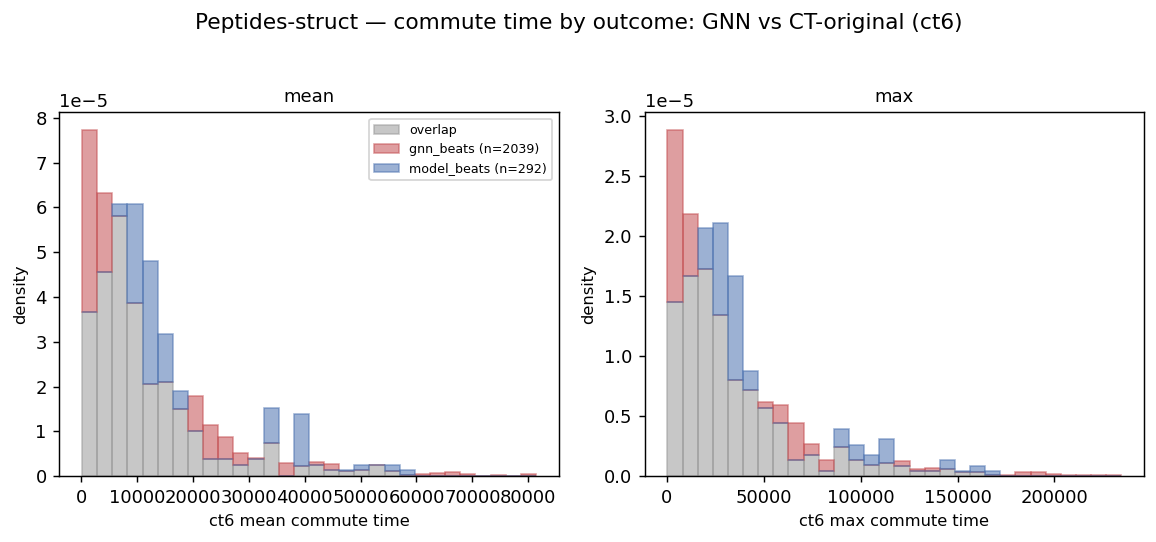

In [140]:
OUTCOME_COLOR = {'gnn_beats': '#C44E52', 'model_beats': '#4C72B0'}
OVERLAP_COLOR = '#999999'

def _commute_vals(prefix, stat, keys):
    arr = commute[prefix][stat]
    vals = np.array([arr[k] for k in keys], dtype=float)
    return vals[~np.isnan(vals)]

def _stacked_hist(ax, vals_a, vals_b, label_a, label_b, color_a, color_b, bins=30):
    """Overlap (gray) as base, per-bin excess of whichever group is taller
    stacked on top in that group's own color. Bars are translucent with a
    solid-color outline so overlapping regions stay readable."""
    all_vals = np.concatenate([vals_a, vals_b])
    edges = np.histogram_bin_edges(all_vals, bins=bins)
    h_a, _ = np.histogram(vals_a, bins=edges, density=True)
    h_b, _ = np.histogram(vals_b, bins=edges, density=True)
    overlap = np.minimum(h_a, h_b)
    excess_a = h_a - overlap
    excess_b = h_b - overlap
    width = edges[1] - edges[0]
    centers = (edges[:-1] + edges[1:]) / 2
    ax.bar(centers, overlap, width=width, color=OVERLAP_COLOR, alpha=0.55,
           edgecolor=OVERLAP_COLOR, linewidth=0.9, label='overlap')
    ax.bar(centers, excess_a, width=width, bottom=overlap, color=color_a, alpha=0.55,
           edgecolor=color_a, linewidth=0.9, label=f'{label_a} (n={len(vals_a)})')
    ax.bar(centers, excess_b, width=width, bottom=overlap, color=color_b, alpha=0.55,
           edgecolor=color_b, linewidth=0.9, label=f'{label_b} (n={len(vals_b)})')

def plot_commute_hist_by_outcome(model_label):
    p = model_prefix(model_label)
    gnn_beats, model_beats = gnn_beats_sets[model_label]
    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    for col, stat in enumerate(('mean', 'max')):
        ax = axes[col]
        _stacked_hist(ax, _commute_vals(p, stat, gnn_beats), _commute_vals(p, stat, model_beats),
                      'gnn_beats', 'model_beats', OUTCOME_COLOR['gnn_beats'], OUTCOME_COLOR['model_beats'])
        ax.set_xlabel(f'{p} {stat} commute time', fontsize=9)
        ax.set_ylabel('density', fontsize=9)
        ax.set_title(stat, fontsize=10)
        if col == 0:
            ax.legend(fontsize=7)
    plt.suptitle(f'Peptides-struct — commute time by outcome: GNN vs {model_label} ({p})', fontsize=12, y=1.03)
    plt.tight_layout()
    plt.show()

plot_commute_hist_by_outcome('CT-original')

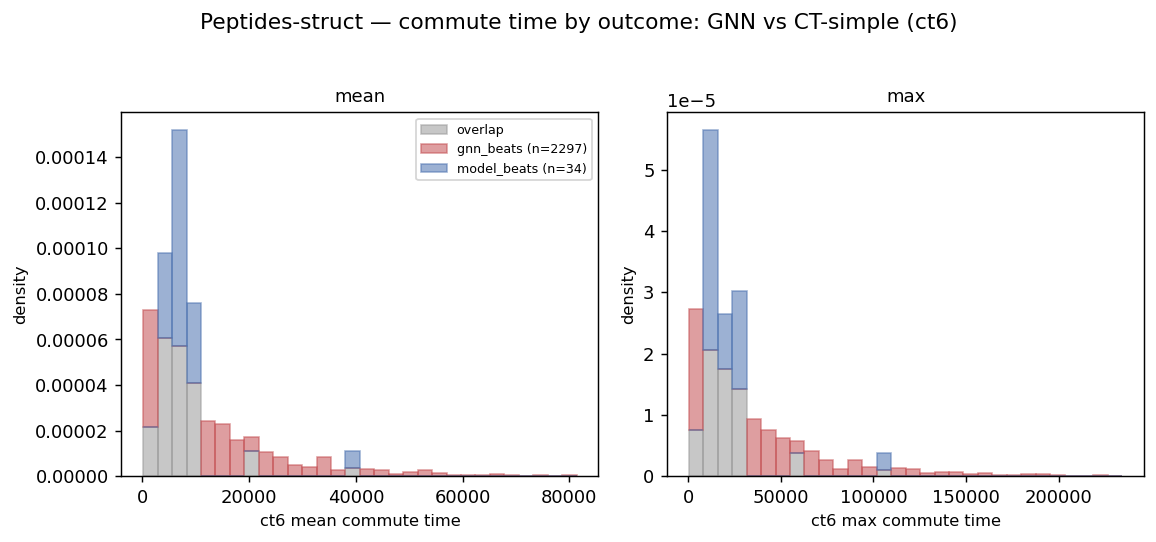

In [141]:
plot_commute_hist_by_outcome('CT-simple')

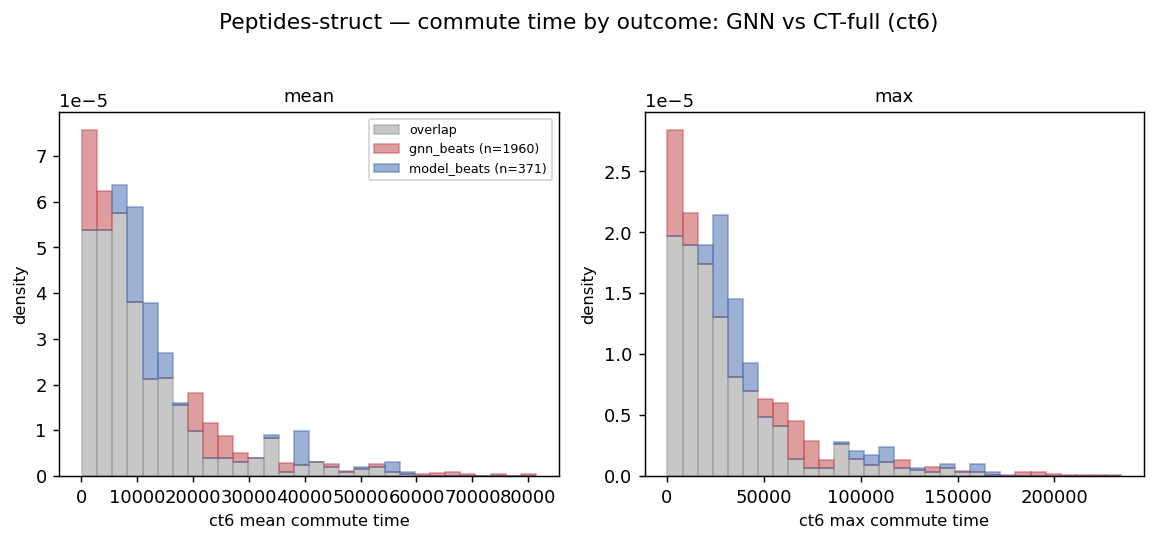

In [142]:
plot_commute_hist_by_outcome('CT-full')

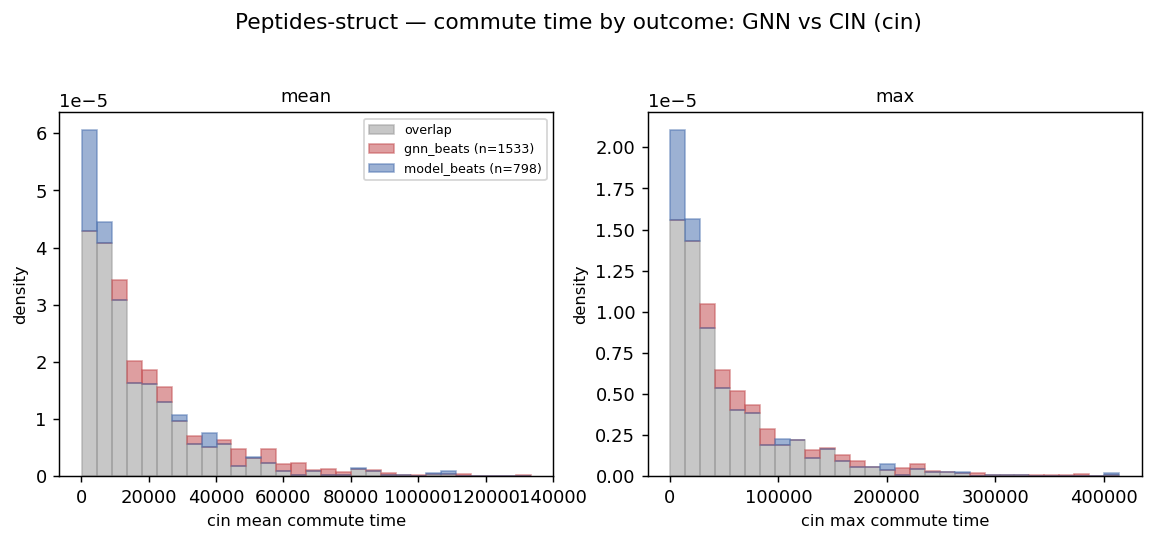

In [143]:
plot_commute_hist_by_outcome('CIN')

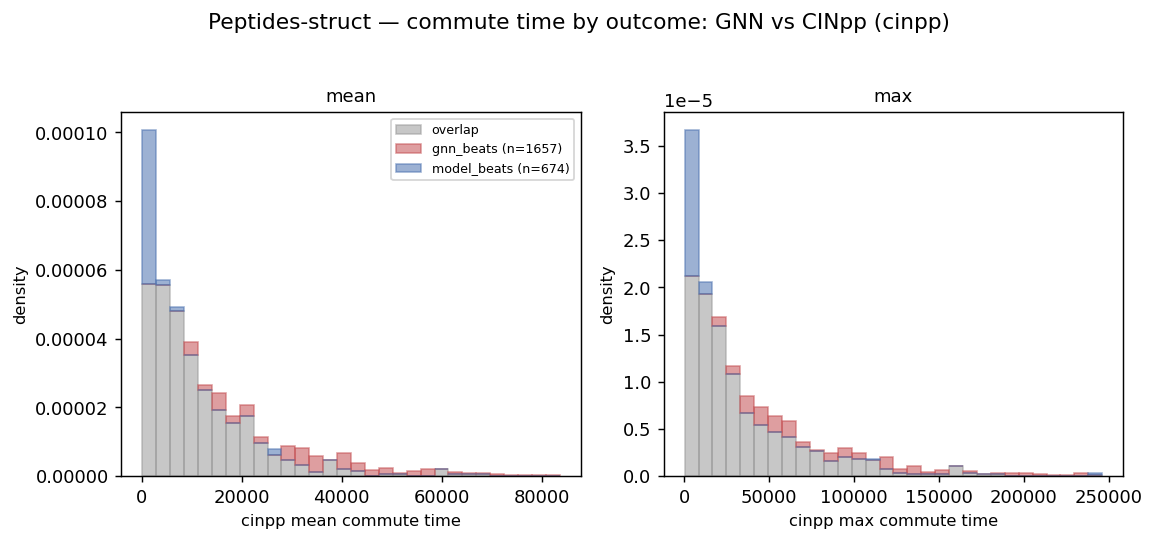

In [144]:
plot_commute_hist_by_outcome('CINpp')

## GNN vs. Other Architectures — Complex/Atom Commute Ratio by Outcome

Same `gnn_beats`/`model_beats` split, but the **raw** ratio `complex_commute / atom_commute` per molecule (not the size-normalized commute time from the earlier section). Only the model's own graph type's ratio is shown (`ct6/atom` for CT variants, `cin/atom` for CIN, `cinpp/atom` for CINpp). Same 3-color scheme: gray = overlap, red = `gnn_beats`-only, blue = `model_beats`-only.

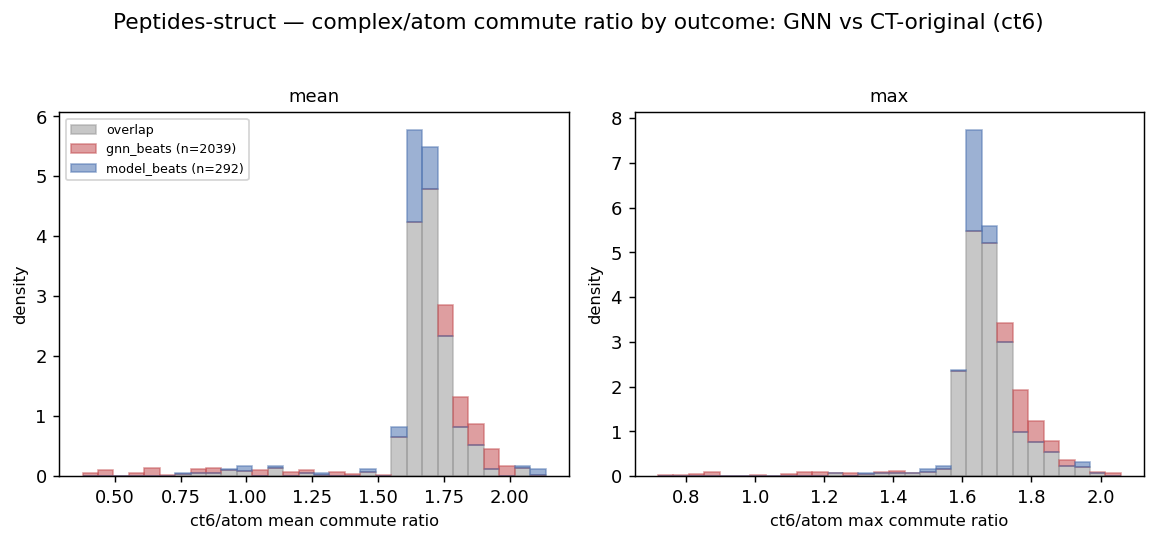

In [145]:
def _ratio_vals(prefix, stat, keys):
    num = commute[prefix][stat]
    den = commute['atom'][stat]
    vals = []
    for k in keys:
        n, d = num[k], den[k]
        if np.isnan(n) or np.isnan(d) or d == 0:
            continue
        vals.append(n / d)
    return np.array(vals, dtype=float)

def plot_ratio_hist_by_outcome(model_label):
    p = model_prefix(model_label)
    gnn_beats, model_beats = gnn_beats_sets[model_label]
    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    for col, stat in enumerate(('mean', 'max')):
        ax = axes[col]
        _stacked_hist(ax, _ratio_vals(p, stat, gnn_beats), _ratio_vals(p, stat, model_beats),
                      'gnn_beats', 'model_beats', OUTCOME_COLOR['gnn_beats'], OUTCOME_COLOR['model_beats'])
        ax.set_xlabel(f'{p}/atom {stat} commute ratio', fontsize=9)
        ax.set_ylabel('density', fontsize=9)
        ax.set_title(stat, fontsize=10)
        if col == 0:
            ax.legend(fontsize=7)
    plt.suptitle(f'Peptides-struct — complex/atom commute ratio by outcome: GNN vs {model_label} ({p})', fontsize=12, y=1.03)
    plt.tight_layout()
    plt.show()

plot_ratio_hist_by_outcome('CT-original')

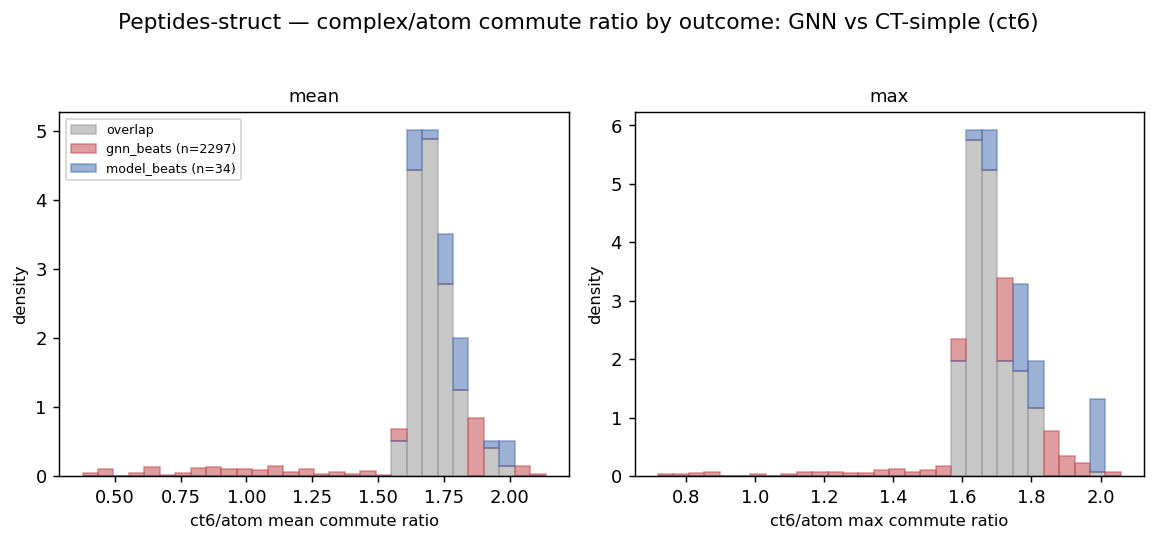

In [146]:
plot_ratio_hist_by_outcome('CT-simple')

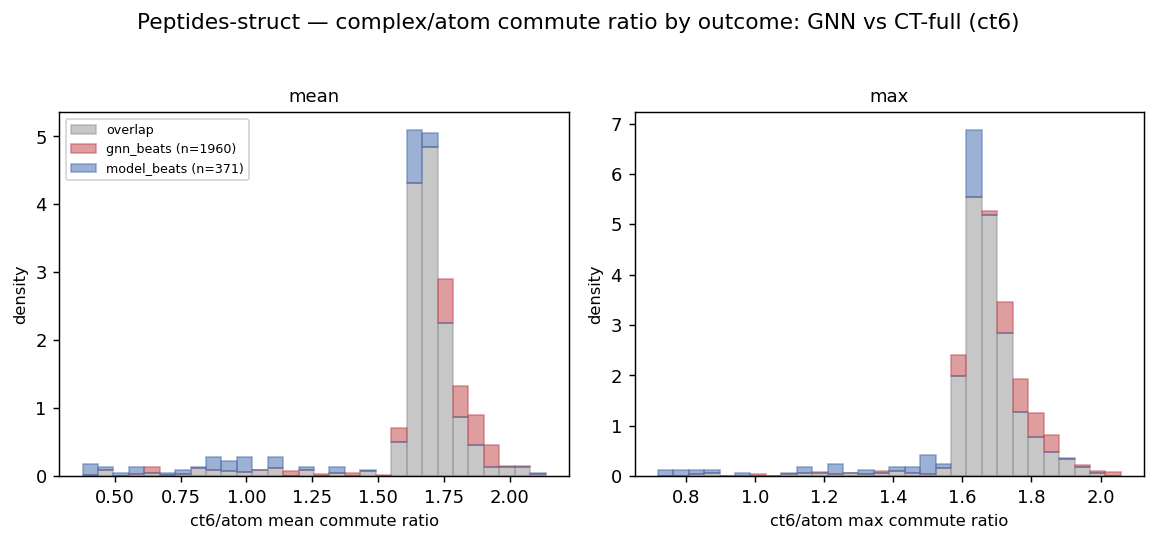

In [147]:
plot_ratio_hist_by_outcome('CT-full')

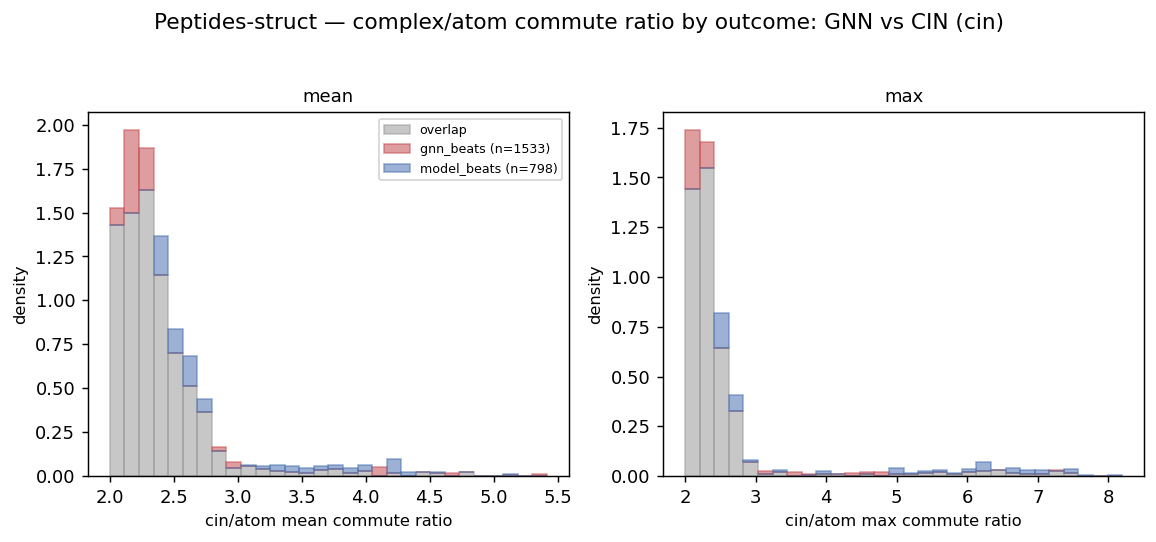

In [148]:
plot_ratio_hist_by_outcome('CIN')

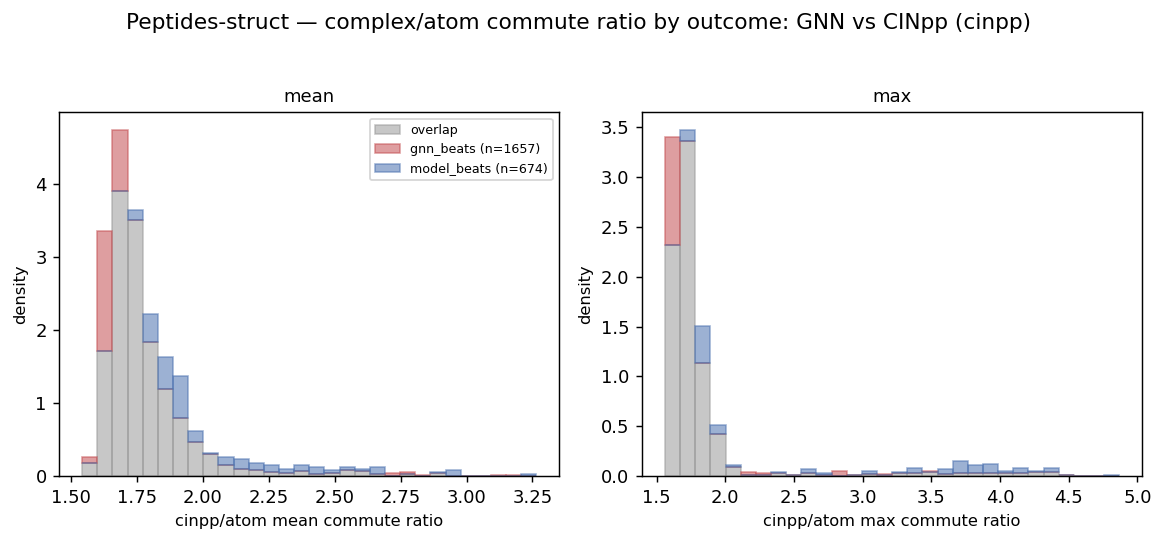

In [149]:
plot_ratio_hist_by_outcome('CINpp')